In [1]:
%load_ext autoreload
%autoreload 2

Follow https://datamapplot.readthedocs.io/en/latest/index.html

In [2]:
import numpy as np
import requests
import io

import datamapplot

/Users/tomasandrade/miniconda3/envs/datamapplot-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data_map_file = requests.get(
    "https://github.com/TutteInstitute/datamapplot/raw/main/examples/arxiv_ml_data_map.npz"
)
arxivml_data_map = np.load(io.BytesIO(data_map_file.content))["arr_0"]
label_file = requests.get(
    "https://github.com/TutteInstitute/datamapplot/raw/main/examples/arxiv_ml_simplified_cluster_labels.npz"
)
arxivml_labels = np.load(io.BytesIO(label_file.content), allow_pickle=True)["arr_0"]

(<Figure size 1000x1000 with 1 Axes>, <Axes: >)

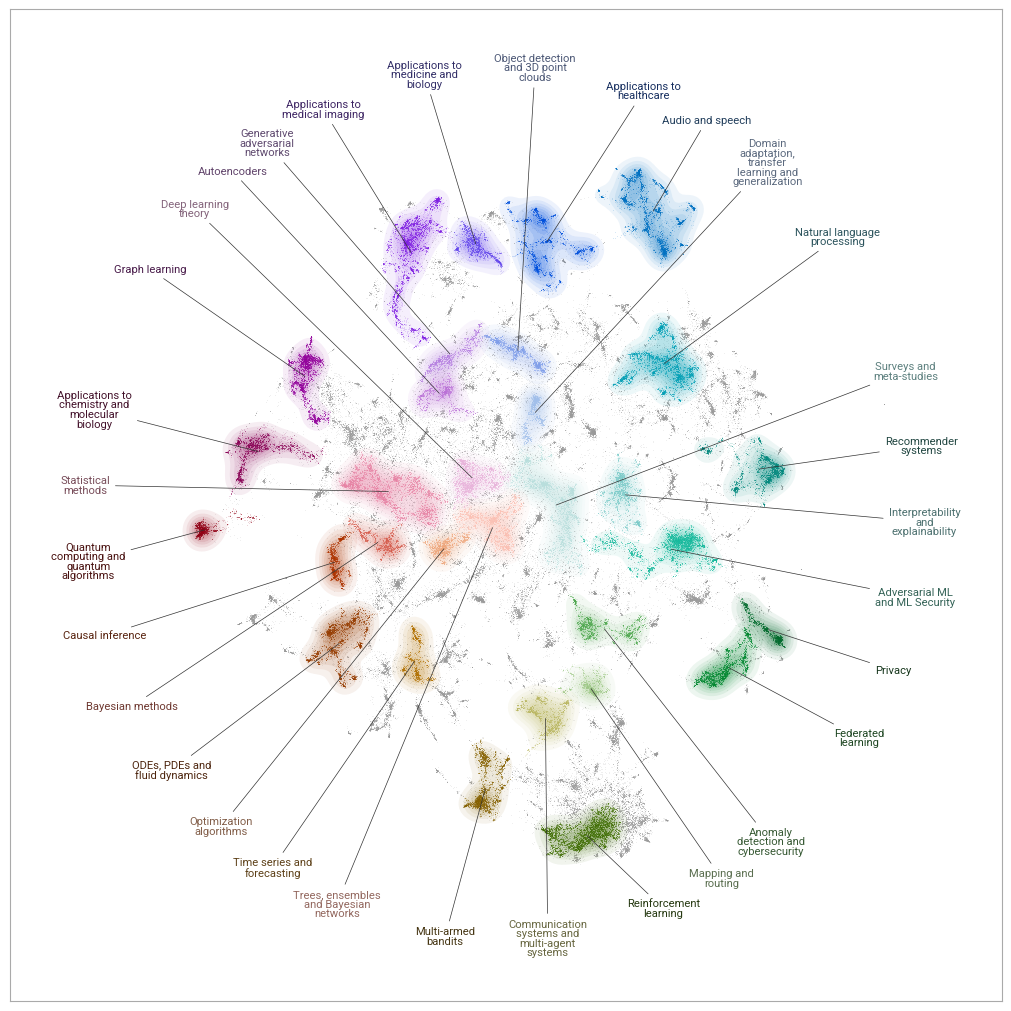

In [4]:
datamapplot.create_plot(arxivml_data_map, arxivml_labels)

In [5]:
base_url = "https://github.com/TutteInstitute/datamapplot"
data_map_file = requests.get(
    f"{base_url}/raw/main/examples/arxiv_ml_data_map.npz"
)
arxivml_data_map = np.load(io.BytesIO(data_map_file.content))["arr_0"]
arxivml_label_layers = []
for layer_num in range(5):
    label_file = requests.get(
        f"{base_url}/raw/main/examples/arxiv_ml_layer{layer_num}_cluster_labels.npz"
    )
    arxivml_label_layers.append(np.load(io.BytesIO(label_file.content), allow_pickle=True)["arr_0"])

In [6]:
hover_data_file = requests.get(
    f"{base_url}/raw/main/examples/arxiv_ml_hover_data.npz"
)
arxiv_hover_data = np.load(io.BytesIO(hover_data_file.content), allow_pickle=True)["arr_0"]

In [10]:
plot = datamapplot.create_interactive_plot(
    arxivml_data_map,
    # arxivml_label_layers[0],
    # arxivml_label_layers[2],
    # arxivml_label_layers[4],
    hover_text = arxiv_hover_data,
    font_family="Playfair Display SC",
)
plot.save("my_plot.html")

In [11]:
ls_file = '/Users/tomasandrade/Documents/BSC/ICHOIR/applio/Applio_LS/siggraph/LS_2d_clean.csv'

In [12]:
import pandas as pd

In [15]:
df = pd.read_csv(ls_file, index_col=0)

array(['b', 'b', 'o', ..., 's', 's', 's'], shape=(142514,), dtype=object)

array(['ES_volver_a_los_17', 'ES_volver_a_los_17', 'ES_volver_a_los_17',
       ..., 'ES_jota', 'ES_jota', 'ES_jota'],
      shape=(142514,), dtype=object)

In [21]:
plot = datamapplot.create_interactive_plot(
    df[['x', 'y']].values,
    df['phone_base'].values,
    # arxivml_label_layers[2],
    # arxivml_label_layers[4],
    hover_text = df['song'].values,
    font_family="Playfair Display SC",
)
plot.save("my_plot.html")